In [22]:
import deepinv as dinv
import torch
import numpy as np
import pywt

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
seed = torch.manual_seed(0)  # Random seed for reproducibility

### Fonction utile pour convertir les coefficients d'ondelette en Numpy vers Torch

In [23]:
def wavelet_numpy_to_torch(coeffs, device=device):
    """
    Convert wavelet coefficients from NumPy arrays to PyTorch tensors.
    """
    approx_np = coeffs[0]
    details_np = coeffs[1:]

    # Convert approximation coefficients
    approx_torch = torch.from_numpy(approx_np.astype(np.float32)).to(device)

    # Convert detail coefficients efficiently
    details_torch = []
    for detail in details_np:
        if isinstance(detail, tuple) and len(detail) == 3:
            # detail is a tuple of (horizontal, vertical, diagonal) arrays
            h_arr, v_arr, d_arr = detail

            # Ensure arrays are contiguous and float32
            h_arr = np.ascontiguousarray(h_arr.astype(np.float32))
            v_arr = np.ascontiguousarray(v_arr.astype(np.float32))
            d_arr = np.ascontiguousarray(d_arr.astype(np.float32))

            # Stack the three arrays into a single array with shape [3, ...]
            detail_stacked = np.stack([h_arr, v_arr, d_arr], axis=0)

            # Convert to torch tensor
            detail_torch = torch.from_numpy(detail_stacked).to(device)
            details_torch.append(detail_torch)
        else:
            # Fallback for other formats
            if not detail.flags.c_contiguous:
                detail = np.ascontiguousarray(detail)
            if detail.dtype != np.float32:
                detail = detail.astype(np.float32)

            detail_torch = torch.from_numpy(detail).to(device)
            details_torch.append(detail_torch)

    return [approx_torch, *details_torch]

### Initialisation du problème

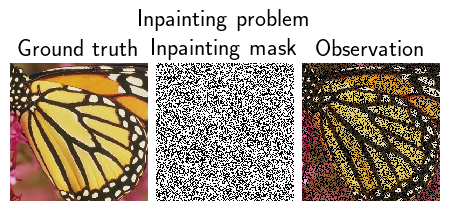

In [24]:
# Ground truth image
x_true = dinv.utils.load_example('butterfly.png', device=device)

# Physics model
sigma = 0.01
#noise_model = dinv.physics.GaussianNoise(sigma=sigma)
physics = dinv.physics.Inpainting(img_size=x_true.shape[1:], mask=0.6, device=device) #, noise_model=noise_model) # Keeping 60% of the pixels

mask = physics.mask.data.to(device)

# Vérification de l'identité A^* = A pour l'inpainting
# dinv.utils.plot(physics.A_adjoint(x_true) - physics.A(x_true))

# Observation
y = physics(x_true)

dinv.utils.plot([x_true, mask, y], titles=['Ground truth', 'Inpainting mask', 'Observation'], suptitle='Inpainting problem')

### Application de l'inpainting dans le domaine ondelettes

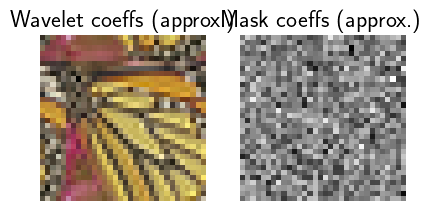

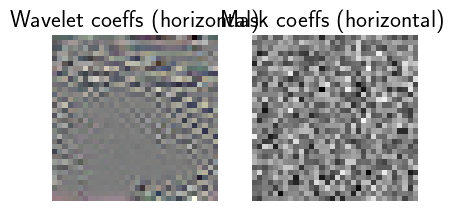

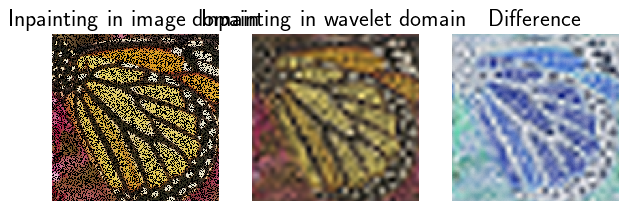

Norm of the difference between the two measurements:  5295.89013671875


In [26]:
# Calcul des coefficients d'ondelettes de l'image et du masque
x_wavelet = wavelet_numpy_to_torch(pywt.wavedec2(x_true.cpu().numpy(), wavelet='db8', level=3, mode='periodization'))
mask_wavelet = wavelet_numpy_to_torch(pywt.wavedec2(mask.cpu().numpy(), wavelet='db8', level=3, mode='periodization'))

# Visualisation de quelques coefficients
dinv.utils.plot([x_wavelet[0], mask_wavelet[0]], titles=['Wavelet coeffs (approx.)', 'Mask coeffs (approx.)'], tight=False)
dinv.utils.plot([x_wavelet[1][0], mask_wavelet[1][0]], titles=['Wavelet coeffs (horizontal)', 'Mask coeffs (horizontal)'], tight=False)

# Définition et application de l'opérateur linéaire à l'échelle la plus grossière
coarse_physics = dinv.physics.Inpainting(img_size=x_wavelet[0].shape[1:], mask=mask_wavelet[0], device=device)#, noise_model=noise_model)
y_wavelet = [coarse_physics(x_wavelet[0])]

# Définitions et applications de l'inpainting dans le domaine des ondelettes pour les détails
for i in range(1, len(x_wavelet)):
    details_tuple = tuple(
        dinv.physics.Inpainting(
            img_size=x_wavelet[i][j].shape[1:],
            mask=mask_wavelet[i][j],
            device=device,
            #noise_model=noise_model
        )(x_wavelet[i][j])
        for j in range(3)
    )
    y_wavelet.append(details_tuple)

# Reconstruire l'observation depuis les coefficients d'ondelettes mesurés
y_recon = pywt.waverec2(y_wavelet, wavelet='db8', mode='periodization')
y_recon = torch.tensor(y_recon, device=device)

# Affichage des résultats
dinv.utils.plot([y, y_recon, y-y_recon], titles=['Inpainting in image domain', 'Inpainting in wavelet domain', 'Difference'], tight=False)
print("Norm of the difference between the two measurements: ", torch.norm(y - y_recon).item())
